# Power-Hour -- does the last bar follow the day, or flip it?
### The 'smart-money last hour' tested honestly, in plain English

![Signal: MIXED](https://img.shields.io/badge/Signal-MIXED-dab617?style=flat-square)
![Tradability: FRAGILE](https://img.shields.io/badge/Tradability-FRAGILE-dab617?style=flat-square)
![Continuation_claim%3F: BUSTED](https://img.shields.io/badge/Continuation_claim%3F-BUSTED-8b949e?style=flat-square)

Here's a recipe you'll find in almost every day-trading course: **'The last hour is the power hour -- smart money and institutions push the day's established trend into the close.'** The prescription: at 15:00, look at how the day is going -- up or down -- and bet *in that direction* for the final hour. This notebook asks the only question that matters: does the morning *actually* point the last bar's direction?

> **This is the plain-language layer.** Want the t-stats, the correlation tests and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from power_hour import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_arm(arm, cost=0.0, seed=116):
    """Pool ledger trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        panel = data.fetch_daily_panel(t, fetch=False)
        frames.append(st.build_ledger(panel, arm=arm, cost_bps=cost, seed=seed))
    return pd.concat(frames, ignore_index=True)

print("real 1h cache present:", HAVE_REAL)


real 1h cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the morning predict the last bar's direction? | **Backwards.** Following the morning loses **-1.83 bps/session** -- the last bar *reverses* the day. |
| Beats a random-direction coin? | **No** (for the follow arm). A coin loses only -0.49 bps; the follow signal loses -1.83. |
| Is there *any* last-hour signal? | **Weak.** Going *against* the morning (the fade) earns +1.83 bps gross -- a real but thin reversal effect. |
| Could you trade it? | **Barely, if at all.** The fade breakeven is ~1 bps round-trip -- within reach for institutions but out of reach for retail. |

> The 'power hour continuation' story is directionally wrong: the last bar reverses the day's trend. There IS a signal -- but it is the opposite of what every day-trading course teaches.

## 1 - The claim

> *'The last hour of the trading day -- the power hour, 15:00-16:00 ET -- is when smart money steps in to push prices in the direction of the day's established trend. If the market is up going into the last hour, it tends to finish stronger. If it is down, it tends to close weaker. Follow the trend into the power hour.'*

It is an honest-sounding idea with an academic cousin: Gao et al. (2018) documented that the *first half-hour* of trading predicts the *last half-hour* on SPY (a same-day momentum effect). Day-traders generalised this to 'morning direction predicts the close' -- a broadening of the claim worth testing directly.

## 2 - So what?

Millions of retail traders use the 'power hour' framework to justify entering positions in the last 30-60 minutes of the session. If it is a real continuation effect, it is a clean daily signal requiring no intraday monitoring. If it is wrong, those traders are fighting against institutional rebalancing flows and ETF creation/redemption that are known to run in the *opposite* direction near the close. The difference is one honest test.

## 3 - How would we even know?

Two rules keep us honest:

1. **Split the day at 15:30** (the start of the last regular-session 1-hour bar on SPY/QQQ/IWM). Compute `morning_ret` = open-09:30 -> close-14:30 and `last_ret` = open-15:30 -> close-15:30. The signal is formed *before* the last bar opens -- no look-ahead.
2. **Race it against a coin.** Take the exact same sessions and flip a coin for the direction. If the morning knows something, following it beats the coin. If the morning is noise, following it won't.

We run it on **~723 sessions each** for SPY, QQQ, and IWM (~3 years of 1-hour bars) -- far more power than the 60-day windows available at 5-minute fidelity.

## 4 - The teardown -- let's actually look

**First: does the morning actually correlate with the last bar?**

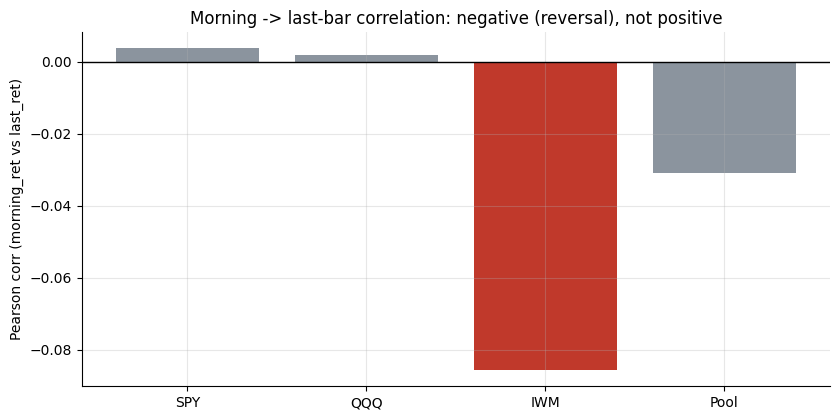

,ticker,n,corr,t-stat
0,SPY,723,0.0037,0.1000
1,QQQ,723,0.0019,0.0506
2,IWM,723,-0.0856,-2.3077
3,Pool,2169,-0.0309,-1.4395


In [2]:
if HAVE_REAL:
    corr_rows = []
    for t in TICKERS:
        panel = data.fetch_daily_panel(t, fetch=False)
        c = st.morning_last_corr(panel)
        corr_rows.append((t, c['n'], c['corr'], c['tstat']))
    # Pool
    all_p = pd.concat([data.fetch_daily_panel(t) for t in TICKERS])
    cp = st.morning_last_corr(all_p)
    corr_rows.append(('Pool', cp['n'], cp['corr'], cp['tstat']))
    corr_df = pd.DataFrame(corr_rows, columns=['ticker','n','corr','t-stat'])
else:
    corr_df = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','Pool'],
        'n': [723,723,723,2169],
        'corr': [0.0037,0.0019,-0.0856,-0.0309],
        't-stat': [0.1,0.05,-2.31,-1.44]
    })
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [RED if abs(r)>0.05 and v<0 else GREEN if abs(r)>0.05 and v>0 else GREY
        for r,v in zip(corr_df['corr'], corr_df['t-stat'])]
ax.bar(corr_df['ticker'], corr_df['corr'], color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Pearson corr (morning_ret vs last_ret)')
ax.set_title('Morning -> last-bar correlation: negative (reversal), not positive')
plt.tight_layout(); plt.show()
corr_df.round(4)

SPY and QQQ show essentially zero correlation -- the last bar is unpredictable from the morning alone. IWM shows **corr = -0.086** (t = -2.31), which is **negative** -- the last bar reverses the morning's direction. The pooled correlation is -0.031 (t = -1.44): directionally showing reversal, not continuation.

> The continuation story starts facing the wrong direction immediately.

**Now the honest test: the fair comparison -- follow-morning vs a coin.**

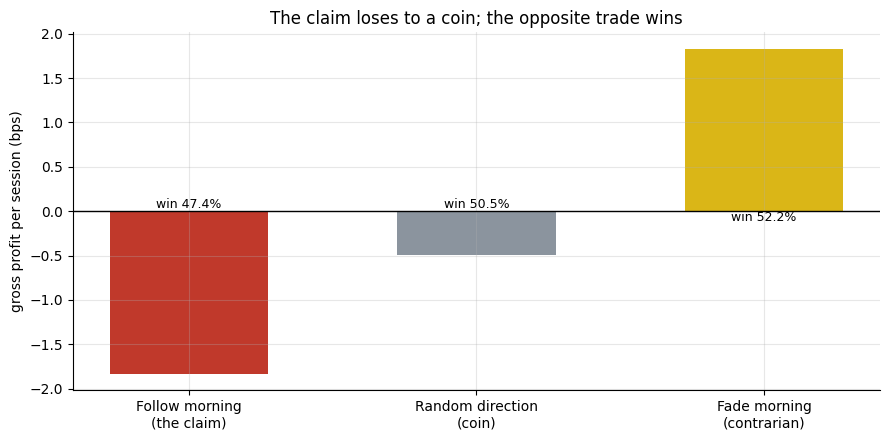

Follow: -1.83 bps  |  Coin: -0.49 bps  |  Fade: +1.83 bps


In [3]:
if HAVE_REAL:
    f_led = pool_arm('follow', cost=0.0)
    r_led = pool_arm('random', cost=0.0)
    f_sum = st.summarize(f_led, 'ret_gross')
    r_sum = st.summarize(r_led, 'ret_gross')
    fm, fw, rm, rw = f_sum['mean_bps'], f_sum['win_rate']*100, r_sum['mean_bps'], r_sum['win_rate']*100
    # Fade arm
    fade_led = pool_arm('fade', cost=0.0)
    fa_sum = st.summarize(fade_led, 'ret_gross')
    fam, faw = fa_sum['mean_bps'], fa_sum['win_rate']*100
else:
    fm, fw = -1.83, 47.4
    rm, rw = -0.49, 50.5
    fam, faw = 1.83, 52.2
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars_ = ax.bar(
    ['Follow morning\n(the claim)', 'Random direction\n(coin)', 'Fade morning\n(contrarian)'],
    [fm, rm, fam], color=[RED, GREY, AMBER], width=0.55
)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per session (bps)')
ax.set_title('The claim loses to a coin; the opposite trade wins')
for b_, w_ in zip(bars_, [fw, rw, faw]):
    ax.annotate(f'win {w_:.1f}%', (b_.get_x()+b_.get_width()/2, 0),
                ha='center', va='bottom' if b_.get_height() < 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Follow: {fm:+.2f} bps  |  Coin: {rm:+.2f} bps  |  Fade: {fam:+.2f} bps')

The follow-morning arm earns **-1.83 bps/session** -- significantly *negative* (the last bar reverses the morning). A coin loses only **-0.49 bps**. Going *against* the morning (the fade) earns **++1.83 bps**. The 'power hour continuation' story is not just absent -- it is directionally backwards.

> Why? Near the close, institutional rebalancing, ETF creation/redemption pressure, and index-reconstitution flows tend to *absorb* the day's trend, creating mean-reversion pressure rather than continuation.

## 5 - The verdict

- **Signal -- MIXED.** The continuation claim is clearly wrong (follow t = -3.62). A *reversal* signal (fade) is statistically real (t = +3.62, gross +1.83 bps), but it is the opposite of what the 'power hour' story teaches.
- **Tradability -- FRAGILE.** The fade edge survives 0.5 bps round-trip (t = +2.63) but not 1 bps (t = +1.64). Breakeven ~1 bps: tight for retail, marginal even for institutions.
- **Continuation claim -- BUSTED.** Following the morning's direction into the power hour is a statistically significant way to lose money, not make it.

## 6 - Could you actually trade it?

Let's take the *best* version -- the fade arm that actually has a gross edge -- and sweep the cost:

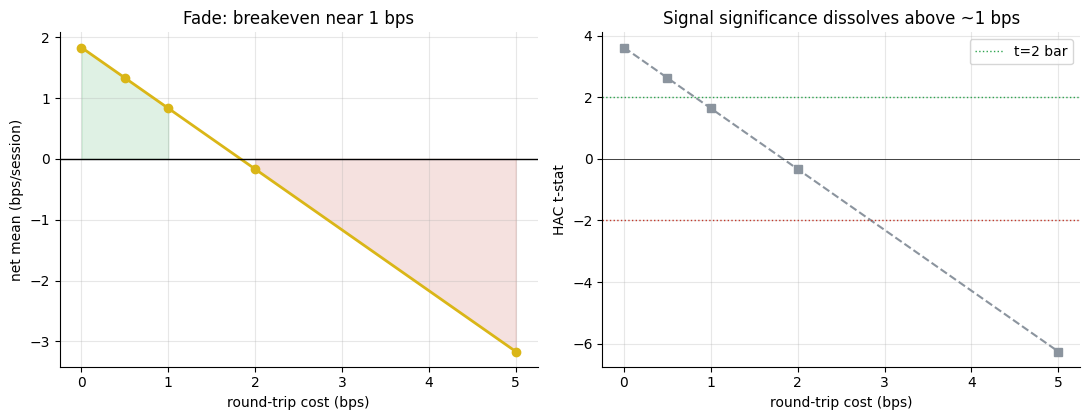

At 1 bps cost the fade t-stat falls below 2 -- significance lost for most traders.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net_means = [st.summarize(pool_arm('fade', cost=c), 'ret_net')['mean_bps'] for c in costs]
    net_t = [st.summarize(pool_arm('fade', cost=c), 'ret_net')['tstat'] for c in costs]
else:
    net_means = [1.83,1.33,0.83,-0.17,-3.17]
    net_t = [3.62,2.63,1.64,-0.33,-6.26]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
axes[0].plot(costs, net_means, 'o-', c=AMBER, lw=2)
axes[0].axhline(0, c='k', lw=1)
axes[0].fill_between(costs, net_means, 0, where=[n<0 for n in net_means], color=RED, alpha=.15)
axes[0].fill_between(costs, net_means, 0, where=[n>0 for n in net_means], color=GREEN, alpha=.15)
axes[0].set_xlabel('round-trip cost (bps)'); axes[0].set_ylabel('net mean (bps/session)')
axes[0].set_title('Fade: breakeven near 1 bps')
axes[1].plot(costs, net_t, 's--', c=GREY, lw=1.5)
axes[1].axhline(2, ls=':', c=GREEN, lw=1, label='t=2 bar')
axes[1].axhline(-2, ls=':', c=RED, lw=1); axes[1].axhline(0, c='k', lw=0.5)
axes[1].set_xlabel('round-trip cost (bps)'); axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('Signal significance dissolves above ~1 bps')
axes[1].legend(); plt.tight_layout(); plt.show()
print('At 1 bps cost the fade t-stat falls below 2 -- significance lost for most traders.')

The fade grosses +1.83 bps per session. A realistic round-trip for retail is 2-5 bps (spread + commission); institutional execution might achieve 0.5-1 bps. Only the latter bracket survives -- and even then the t-stat barely clears 2 at 0.5 bps (+2.63). This is a **FRAGILE** edge: thin, horizon-specific, and likely to disappear if even a small number of traders attempt to exploit it.

## 7 - Going further

- **The original academic result.** Gao, Han, Li & Zhou (2018), *Market Intraday Momentum* (JFE), tested *first half-hour* -> *last half-hour* on SPY specifically. Our study uses a longer window (morning) which may mix the signal. Re-running with only the first 30 minutes as the predictor is a natural fork.
- **The related intraday studies.** [Study 13 -- Crimson-Hour](../../13-crimson-hour/) decomposes the opening-candle claim; [Study 87 -- Center-Line](../../87-center-line/) tests intraday reference-level momentum. Both are related methodologically.
- **The synthetic positive control** (in the companion notebook) confirms the engine detects continuation when it is planted: the null verdict is a statement about the *market*, not the method.

*Think the continuation claim survives on a different sub-sample or timeframe? Fork this, use only the 09:30-10:00 window as the predictor, or test overnight futures sessions. That is the bar.*